# Requirement 2 — Multiple Campaigns, Stochastic Environment

Just like the Requirement 1 notebook, every code cell here is preceded by a short paragraph explaining *what we're about to do and why*, and followed by a paragraph explaining *how to read the result*. This notebook builds directly on Requirement 1 — if anything here is unclear, it's worth re-reading the corresponding part of `requirement1_single_campaign.ipynb` first, since we reuse almost all of its building blocks.

### A note on this version

This version solves the per-round combinatorial decision with an **integer program** (`scipy.optimize.milp`), the same tool the practical sessions' `09_combinatorial_mabs.ipynb` notebook uses for its matching (`linear_sum_assignment` is a special case of this) and knapsack agents. An earlier draft of this notebook instead brute-force listed every feasible "bundle" of campaigns-and-bids and looped over the list each round; that approach still appears below, but only as an **optional reference/validation tool** — it is no longer what the actual agents use to decide how to bid.

### What Requirement 2 asks for

Recall from `project.pdf`: we now have **multiple** campaigns $i = 1, \dots, N$ sharing **one** budget, running in a **stochastic** environment, with an extra twist — a *conflict graph* saying which campaigns can't run at the same time (e.g. Coca-Cola and Pepsi). We must:

1. Build a stochastic environment: **a joint distribution over the highest competing bids for each campaign**.
2. Build a bidding strategy using **Combinatorial-UCB with a budget constraint**.

> **Hint from the project**: *"Extend the 'UCB-like' approach that we saw for a single campaign to multiple campaigns."*

That "UCB-like approach" is Algorithm 2 from Requirement 1 (`UCBBiddingAgent`) — UCB on reward, LCB on cost, an optimization problem solved each round to decide how to bid within budget. Requirement 2 is that same idea, just applied to a much richer action space: instead of "pick one bid out of 11", the decision each round becomes "pick one *compatible group of campaigns*, and a bid for each campaign in that group." Here, we solve that per-round decision the way the practical sessions solve combinatorial problems in general: as an integer program.

### The rules of the game (recap, extended to $N$ campaigns)

At every round $t$:

1. We choose, for each campaign $i$, either "don't bid this round" or a bid $b_{i,t} \in \mathcal{B}$ — subject to the **conflict graph**: the set of campaigns we bid on this round must be an *independent set* (no two conflicting campaigns both included).
2. For every campaign $i$ we do bid on, a first-price auction runs against a competing bid $m_{i,t}$, sampled from a fixed distribution (jointly across campaigns, i.i.d. across rounds — this is the "stochastic environment").
3. We win campaign $i$ iff $b_{i,t} \ge m_{i,t}$. If we win: utility $f_{i,t} = v_i - b_{i,t}$, cost $c_{i,t} = b_{i,t}$; otherwise both are $0$.
4. All the costs across *every* campaign we won this round are subtracted from the **same shared budget** $B_0$. Once $B_0$ is nearly gone, we stop bidding on anything.

We still only observe $f_{i,t}, c_{i,t}$ for the campaigns we actually bid on this round (bandit feedback) — nothing for the campaigns we skipped.


### Step 0 — Load the tools we need

Same imports as Requirement 1, plus `itertools` (used only by the optional brute-force reference tool in Section 3), `LinearConstraint`/`Bounds`/`milp` from `scipy.optimize` — the integer-programming solver, exactly as used for the matching and knapsack agents in `09_combinatorial_mabs.ipynb` — and now also `networkx`, the same graph library `09_combinatorial_mabs.ipynb` uses to draw its bipartite matching pictures. We use it here to actually build and visualize the conflict graph, rather than just checking membership in a list of edge-tuples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from scipy import optimize
from scipy.optimize import milp, LinearConstraint, Bounds
import itertools


No visible output — this just loads the libraries.

## 1. The auction mechanism

### We reuse Requirement 1's auction unchanged

Nothing changes here: each campaign still runs its *own*, independent first-price auction each round (whoever bids highest on that campaign's slot wins it, and pays their own bid). We simply reuse the exact same `Auction` / `FirstPriceAuction` classes from Requirement 1 — copy-pasted verbatim — since the project doesn't change how any *individual* campaign's auction works; what's new is only which campaigns we're allowed to enter at the same time, and how we split one budget across all of them.

In [2]:
class Auction:
    def __init__(self, *args, **kwargs):
        pass

    def get_winners(self, bids):
        pass

    def get_payments_per_click(self, winners, bids):
        pass

    def round(self, bids):
        winners = self.get_winners(bids)
        payments_per_click = self.get_payments_per_click(winners, bids)
        return winners, payments_per_click


class FirstPriceAuction(Auction):
    def __init__(self, qs):
        self.qs = qs
        self.n_adv = len(self.qs)

    def get_winners(self, bids):
        public_values = self.qs * bids
        public_ranking = np.argsort(public_values)
        winner = public_ranking[-1]
        return winner

    def get_payments_per_click(self, winners, bids):
        payment = bids[winners]
        return payment


No output — just definitions, identical to Requirement 1. As in the earlier version, we won't even instantiate `FirstPriceAuction` explicitly for every campaign; since we only need "did bid $b$ beat competing bid $m$", the environment below checks that directly — mathematically the exact same first-price rule, just without the extra bookkeeping of a full multi-bidder auction object.

## 2. The conflict graph and the stochastic environment

### 2.1 — The conflict graph

The project's example is Coca-Cola vs. Pepsi: the agency can't run both campaigns in the same round. We represent this as a graph: one node per campaign, and an edge between two campaigns that are *not* compatible. We pick a small, concrete example to work with throughout this notebook:

- $N = 3$ campaigns, indexed $0, 1, 2$.
- One conflict: campaigns $0$ and $1$ cannot both run in the same round (think "Coke" and "Pepsi").
- Campaign $2$ is compatible with everything (think "toothpaste" — no rivalry with either soda brand).

A **feasible set of campaigns to bid on** in a given round is exactly an *independent set* of this graph — any subset of $\{0,1,2\}$ that doesn't contain both $0$ and $1$.

We now build this as an actual `networkx.Graph()` object — the same library `09_combinatorial_mabs.ipynb` uses for its bipartite matching pictures — rather than just a bare list of edge-tuples. The key difference from a *matching* graph is what an edge *means*: in the matching notebook, an edge is a *compatible* pairing worth including; here, an edge is the opposite — an *incompatible* pairing that must never both appear in the same bundle. Everything downstream (`conflict_edges`, used to build the MILP's structural constraints in Section 4) is derived directly from this graph object, so the picture below and the optimization constraints are guaranteed to always agree.

In [3]:
N = 3   # number of campaigns

conflict_graph = nx.Graph()
conflict_graph.add_nodes_from(range(N))
conflict_graph.add_edge(0, 1)   # campaign 0 and campaign 1 cannot both run in the same round

conflict_edges = list(conflict_graph.edges())   # everything downstream reads this, not a hand-written list

def is_independent_set(campaign_subset, edges):
    campaign_subset = set(campaign_subset)
    return not any(i in campaign_subset and j in campaign_subset for i, j in edges)

# sanity check
for subset in [(), (0,), (1,), (2,), (0, 1), (0, 2), (1, 2), (0, 1, 2)]:
    print(f'{subset}: {"feasible" if is_independent_set(subset, conflict_edges) else "NOT feasible (conflict)"}')


(): feasible
(0,): feasible
(1,): feasible
(2,): feasible
(0, 1): NOT feasible (conflict)
(0, 2): feasible
(1, 2): feasible
(0, 1, 2): NOT feasible (conflict)


**Reading the output**: every subset is feasible ("compatible") *except* the two that include both campaign $0$ and campaign $1$ together — exactly as intended. This little `is_independent_set` check is the computational form of "the conflict graph" described in the project; we'll turn it into actual optimization constraints (rather than a lookup) in Section 4, using `conflict_edges = list(conflict_graph.edges())` from the very graph object we just built.

### 2.1b — Drawing the conflict graph (mirroring `09_combinatorial_mabs.ipynb`)

Notebook 09 defines `plot_weighted_bipartite`/`plot_weighted_matching` to *see* which worker-task edges are being used. We do the same thing here for our conflict graph: `nx.draw_networkx` on a layout of the graph, with node/edge colors used to highlight whatever we want to draw attention to (a candidate bundle, a blocked pair, and so on).

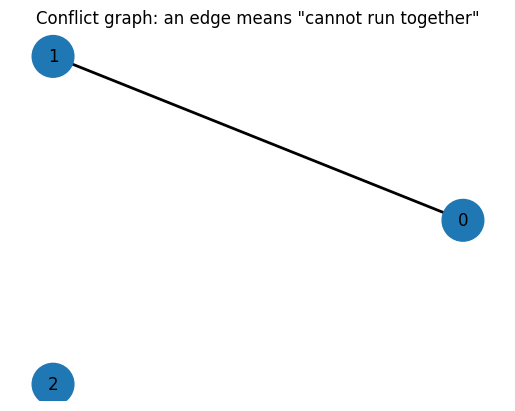

In [4]:
def plot_conflict_graph(graph, highlight_nodes=None, blocked_edge=None, title='Conflict graph'):
    # Same nx.Graph() + nx.draw_networkx machinery as plot_weighted_bipartite/plot_weighted_matching
    # in 09_combinatorial_mabs.ipynb, adapted to a plain (non-bipartite) graph: nodes = campaigns,
    # edges = "cannot run together" (the opposite meaning of an edge in a matching problem).
    pos = nx.circular_layout(graph)
    node_colors = ['tab:orange' if highlight_nodes and n in highlight_nodes else 'tab:blue'
                   for n in graph.nodes()]
    edge_colors = ['red' if blocked_edge and set(e) == set(blocked_edge) else 'black'
                   for e in graph.edges()]
    nx.draw_networkx(graph,
                      pos=pos,
                      node_color=node_colors,
                      edge_color=edge_colors,
                      width=2,
                      node_size=900,
                      with_labels=True)
    plt.title(title)
    plt.axis('off')
    plt.show()


plot_conflict_graph(conflict_graph, title='Conflict graph: an edge means "cannot run together"')


**Reading this picture**: three nodes (campaigns $0$, $1$, $2$), one edge between $0$ and $1$ (the Coke/Pepsi conflict), and campaign $2$ floating with no edges at all — meaning it's compatible with everything. This is the entire "conflict graph" the project asks for, drawn exactly the way `09_combinatorial_mabs.ipynb` draws its own graphs.

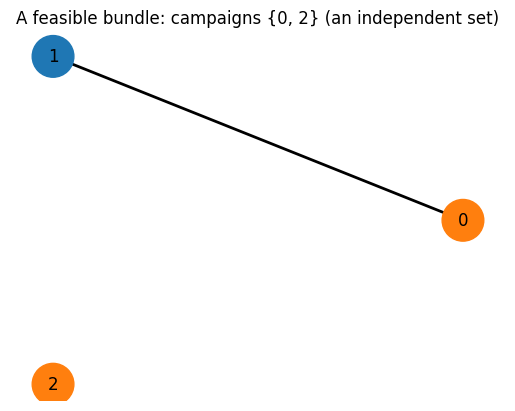

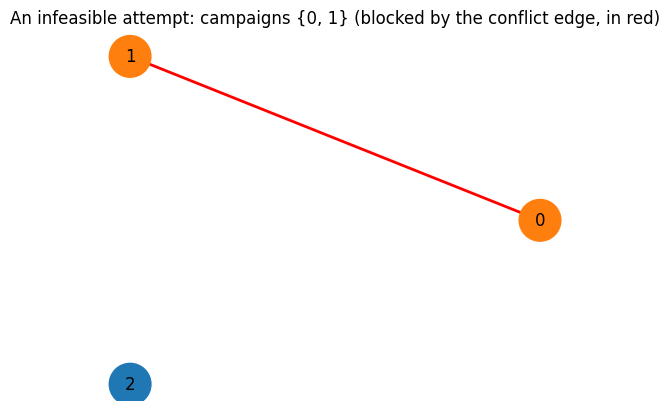

In [5]:
plot_conflict_graph(conflict_graph, highlight_nodes={0, 2},
                     title='A feasible bundle: campaigns {0, 2} (an independent set)')

plot_conflict_graph(conflict_graph, highlight_nodes={0, 1}, blocked_edge=(0, 1),
                     title='An infeasible attempt: campaigns {0, 1} (blocked by the conflict edge, in red)')


**Reading these two pictures**: the first highlights $\{0,2\}$ in orange — no edge connects the two highlighted nodes, so this is a valid independent set and can legally appear together in a played bundle. The second highlights $\{0,1\}$ and turns the edge between them red — a visual flag that this pair is *not* an independent set, i.e. exactly the case `is_independent_set` rejects above and that the conflict-edge row of `build_structural_constraints` (Section 4) rules out algebraically. The graph, the `is_independent_set` check, and the MILP's constraint row are three views of the same fact.

### 2.2 — The stochastic environment: a *joint* distribution over competing bids

The project asks for "a joint distribution over the highest competing bids for each campaign" — i.e. we need a rule for how $(m_{1,t}, m_{2,t}, m_{3,t})$ are generated together each round. The simplest valid example of a joint distribution is a **product of independent marginals**: each campaign's competing bid is drawn from its own distribution, independently of the others. This is a perfectly legitimate (if simple) joint distribution, and — exactly as in Requirement 1 — we reuse the $\mathrm{Beta}(n,1)$ trick, giving each campaign a different number of "effective competitors" $n_i$, so that some campaigns are easier to win than others.

*(If your real project wants genuinely correlated competition across campaigns — e.g. "when competition is fierce for Coke, it's also fierce for Pepsi" — you would replace this with a real joint sampler. Everything downstream only needs `m_distribution.rvs(size=T)` to produce the $T\times N$ matrix of competing bids, so swapping in a correlated sampler doesn't require changing anything else in this notebook.)*

In [6]:
class MultiCampaignEnvironment:
    # Stochastic environment for Requirement 2: N campaigns, each running its own
    # first-price auction, with a joint (here: independent-marginals) distribution
    # over the campaigns' highest competing bids m_{i,t}.
    def __init__(self, valuations, m_distributions, T, seed=None):
        self.valuations = np.asarray(valuations)
        self.N = len(valuations)
        self.T = T
        rng = np.random.default_rng(seed)
        # self.m_t has shape (T, N): one competing bid per campaign, per round
        self.m_t = np.column_stack([d.rvs(size=T, random_state=rng) for d in m_distributions])
        self.t = 0

    def round(self, bundle):
        # bundle: list of (campaign_index, bid_VALUE) pairs, bid_VALUE in [0, 1] — the campaigns
        # we bid on this round, and the actual bid amount for each (NOT a bid index!). The agents'
        # pull() returns bid *indices* (for fast array lookups); always convert with
        # bundle_to_bid_values() below before calling this method.
        f_vec = np.zeros(self.N)
        c_vec = np.zeros(self.N)
        win_vec = np.zeros(self.N, dtype=int)
        for i, b in bundle:
            m_i = self.m_t[self.t, i]
            win = int(b >= m_i)
            f_vec[i] = (self.valuations[i] - b) * win
            c_vec[i] = b * win
            win_vec[i] = win
        self.t += 1
        return f_vec, c_vec, win_vec


**What this class does**: it's the direct multi-campaign generalization of Requirement 1's `SingleCampaignEnvironment`. The only real difference is that `round()` now takes a **bundle** — a list of `(campaign_index, bid_value)` pairs, one for every campaign we're choosing to bid on this round — and returns a length-$N$ vector for each of utility, cost, and win/lose, with zeros in the slots for campaigns we didn't bid on. As before, all randomness is pre-generated for reproducibility; the agent still only ever sees one round's outcome at a time. (The agents further below track statistics using bid *indices*, not values — Section 2.3b defines the small helper that converts between the two.)

### 2.3 — Concrete numbers for the example

As in Requirement 1, these are **illustrative placeholders**:

- `valuations = [0.7, 0.5, 0.6]`: campaign $0$ (say, a premium product) is worth the most per win, campaign $2$ the least.
- `n_competitors = [3, 2, 4]`: campaign $1$ faces the *weakest* competition (fewest effective rivals, $n=2$), campaign $2$ the *strongest* ($n=4$) — just to make the three campaigns meaningfully different.
- `available_bids`: the same 11-value grid as Requirement 1, used for every campaign.
- `T = 2500`, `B = 75` (so $\rho = B/T = 0.03$): the whole multi-campaign operation shares this one budget and horizon.

We print the win-probability curve for each campaign separately below.

In [7]:
valuations = np.array([0.7, 0.5, 0.6])   # v_i for each campaign
n_competitors = [3, 2, 4]                # used only to build each campaign's illustrative Beta(n,1) distribution

T = 2500
B = 75
rho = B / T

available_bids = np.linspace(0, 1, 11)   # same discretized bid set for every campaign
n_bids = len(available_bids)

m_distributions = [stats.beta(n, 1) for n in n_competitors]
win_probabilities = np.array([d.cdf(available_bids) for d in m_distributions])   # shape (N, n_bids)

print(f'N={N} campaigns, T={T}, B={B}, rho={rho:.4f}')
print(f'valuations={valuations}')
for i in range(N):
    print(f'campaign {i}: win_probabilities={np.round(win_probabilities[i], 3)}')


N=3 campaigns, T=2500, B=75, rho=0.0300
valuations=[0.7 0.5 0.6]
campaign 0: win_probabilities=[0.    0.001 0.008 0.027 0.064 0.125 0.216 0.343 0.512 0.729 1.   ]
campaign 1: win_probabilities=[0.   0.01 0.04 0.09 0.16 0.25 0.36 0.49 0.64 0.81 1.  ]
campaign 2: win_probabilities=[0.    0.    0.002 0.008 0.026 0.062 0.13  0.24  0.41  0.656 1.   ]


**Reading the output**: `win_probabilities` is now a $3 \times 11$ table instead of Requirement 1's single row — one win-probability curve per campaign. Campaign $1$ (fewer competitors, $n=2$) should show *higher* win probabilities at any given bid than campaign $2$ (more competitors, $n=4$) — it's "easier" to win, all else equal.

### 2.3b — Bridging the agents' index-based bundles to the environment's bid values

One bookkeeping detail worth making explicit, since it's easy to get wrong: every agent below (`CombinatorialUCBAgent`, `CombinatorialUCBBiddingAgent`) works with **bid indices** ($0, \dots, 10$), because that's what lets `avg_f`, `avg_c`, `N_pulls`, and the MILP's flat variable array be simple, fast NumPy arrays indexed by `(campaign, bid_index)`. `MultiCampaignEnvironment.round()`, on the other hand, needs the **actual bid amount** ($0.0$ to $1.0$) for each campaign, since that's what determines whether the bid beats the competing bid $m_{i,t}$ and how much gets paid. We convert between the two with one small helper, used every time a bundle is hand off from an agent to the environment.

In [8]:
def bundle_to_bid_values(bundle):
    # (campaign_index, bid_index) pairs, as returned by agent.pull() -> (campaign_index, bid_value) pairs
    return [(i, available_bids[b]) for i, b in bundle]


No output — just a definition. Note that `agent.update(bundle, ...)` always keeps using the original **index**-based bundle (it needs indices to update `avg_f`/`avg_c`/`N_pulls`), while `env.round(...)` always gets the **value**-converted bundle via `bundle_to_bid_values`. Every experiment loop below follows this pattern.

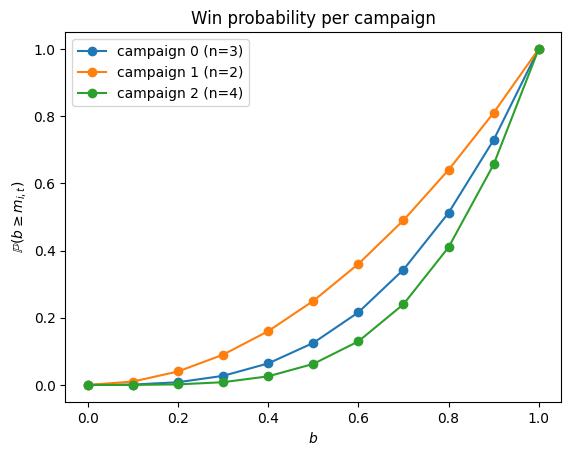

In [9]:
plt.figure()
for i in range(N):
    plt.plot(available_bids, win_probabilities[i], marker='o', label=f'campaign {i} (n={n_competitors[i]})')
plt.title('Win probability per campaign')
plt.xlabel('$b$')
plt.ylabel('$\\mathbb{P}(b \\geq m_{i,t})$')
plt.legend()
plt.show()


**How to read this graph**: three S-shaped curves, one per campaign, all rising from $0$ to $1$ just like Requirement 1's single curve. The campaign with fewer competitors ($n=2$) sits *above* the others — the same bid wins more often for it — while the campaign with more competitors ($n=4$) sits *below*. This is exactly the kind of heterogeneity across campaigns that a real agency would face, and it's what makes the "which campaigns should I even bother bidding on" decision non-trivial.

## 3. The combinatorial action space, and an optional brute-force reference tool

### The key new idea in Requirement 2

In Requirement 1 the agent chose one thing per round: a single bid, out of $11$ options. Here, the agent has to choose an entire **bundle**: a *compatible* subset of campaigns, together with a bid for each campaign in that subset.

For our example ($N=3$, one conflict edge, $11$ bids), the feasible campaign-subsets are: $\varnothing$, $\{0\}$, $\{1\}$, $\{2\}$, $\{0,2\}$, $\{1,2\}$ (every subset **except** the two containing both $0$ and $1$). For each non-empty subset, we then need a bid for *every* campaign inside it, so a subset of size $2$ contributes $11 \times 11 = 121$ different bundles. Altogether that's a few hundred feasible bundles — far more than Requirement 1's $11$ bids.

### Two ways to search this action space

There are two ways to have the agent pick the best bundle each round:

1. **List every feasible bundle and score each one** (brute force). Simple and fully transparent, but it only works because our example is tiny — it wouldn't scale to more campaigns or finer bid grids, since the number of bundles grows combinatorially.
2. **Formulate it as an integer program and hand it to a solver** — exactly what the practical sessions do for combinatorial problems (`linear_sum_assignment` for the matching agent, `scipy.optimize.milp` for the knapsack agent). This is what our actual agents use below, in Section 4 onward.

We keep the brute-force version here only as a small **reference/validation tool** — useful for sanity-checking that the integer-program solver is finding the true best bundle on a small example, and for the one-time (offline) computation of the benchmark in Section 5. It is *not* used inside the online learning agents.

In [10]:
def feasible_campaign_subsets(N, edges):
    subsets = []
    for r in range(N + 1):
        for combo in itertools.combinations(range(N), r):
            if is_independent_set(combo, edges):
                subsets.append(combo)
    return subsets


def enumerate_bundles(N, edges, n_bids):
    # OPTIONAL / REFERENCE ONLY — not used by the online agents below.
    bundles = []
    for subset in feasible_campaign_subsets(N, edges):
        if len(subset) == 0:
            bundles.append(())          # the "bid on nothing" bundle
        else:
            for bid_combo in itertools.product(range(n_bids), repeat=len(subset)):
                bundles.append(tuple(zip(subset, bid_combo)))
    return bundles


def best_bundle_bruteforce(bundles, values, costs=None, rho=None):
    # OPTIONAL / REFERENCE ONLY: exact best bundle by exhaustive search.
    # If costs/rho are given, only considers bundles with total cost <= rho.
    best_val, best_bd = -np.inf, ()
    for bd in bundles:
        val = sum(values[i, b] for i, b in bd)
        if costs is not None:
            cst = sum(costs[i, b] for i, b in bd)
            if cst > rho:
                continue
        if val > best_val:
            best_val, best_bd = val, bd
    return best_bd, best_val


BUNDLES = enumerate_bundles(N, conflict_edges, n_bids)
print(f'Number of feasible campaign subsets: {len(feasible_campaign_subsets(N, conflict_edges))}')
print(f'Total number of feasible bundles (subset x bid combinations): {len(BUNDLES)}')


Number of feasible campaign subsets: 6
Total number of feasible bundles (subset x bid combinations): 276


**Reading the output**: $276$ feasible bundles for our example: the empty bundle, $3 \times 11 = 33$ single-campaign bundles, and $2 \times 11 \times 11 = 242$ two-campaign bundles (only $\{0,2\}$ and $\{1,2\}$ are allowed as pairs) — $1 + 33 + 242 = 276$. We'll use `BUNDLES` and `best_bundle_bruteforce` in exactly two places later: once to double-check the integer-program solver agrees with exhaustive search (Section 4), and once to compute the offline clairvoyant benchmark (Section 5) — never inside the agents' per-round decision loop.

## 4. Solving the per-round decision as an integer program

### Why we don't need $276$ independent sets of statistics

A bundle's value is just the *sum* of its components' values,
$$
\bar f(\text{bundle}) = \sum_{(i,b) \,\in\, \text{bundle}} \bar f_i(b), \qquad \bar c(\text{bundle}) = \sum_{(i,b) \,\in\, \text{bundle}} \bar c_i(b).
$$
So we only ever need to *learn* statistics at the much smaller granularity of individual $(\text{campaign}, \text{bid})$ pairs — there are only $N \times 11 = 33$ of those — and then, each round, *compose* those learned estimates into a decision. Playing any bundle gives us feedback on every $(\text{campaign}, \text{bid})$ pair inside it simultaneously (this is called **semi-bandit feedback**), which is exactly why learning stays tractable.

### Formulating "pick the best feasible bundle" as an integer program

Introduce one binary decision variable $x_{i,b} \in \{0,1\}$ for every $(\text{campaign } i, \text{bid } b)$ pair, meaning "we bid $b$ on campaign $i$ this round." The optimization problem is:

$$
\max_{x \,\in\, \{0,1\}^{N \times |\mathcal{B}|}} \ \sum_{i,b} x_{i,b}\, V_i(b)
\qquad \text{s.t.} \qquad
\underbrace{\sum_b x_{i,b} \le 1 \ \ \forall i}_{\text{at most one bid per campaign}},
\qquad
\underbrace{\sum_b x_{i,b} + \sum_b x_{j,b} \le 1 \ \ \forall (i,j)\in\text{edges}}_{\text{conflict graph}}
$$

where $V_i(b)$ is whatever score we're optimizing (a plain average for the no-budget version, a UCB estimate once we're learning). This is a small integer *linear* program: the objective and every constraint are linear in $x$, and `scipy.optimize.milp` — the exact same solver used for the knapsack agent in the practical sessions — solves it directly, no bundle enumeration required. The two families of constraints above encode *exactly* the two feasibility rules from Section 2–3 ("one bid per campaign", "respect the conflict graph"), just written as inequalities instead of a Python filter.

Because the *feasibility structure* (which campaigns conflict) never changes round to round, we build the constraint matrix for these two constraint families **once**, and reuse it for every solve — only the objective coefficients $V_i(b)$ (and, later, an extra budget row) change from round to round.

In [11]:
def flat_index(i, b, n_bids):
    return i * n_bids + b


def build_structural_constraints(N, n_bids, edges):
    # One row per campaign ("at most one bid"), plus one row per conflict edge.
    rows = []
    for i in range(N):
        row = np.zeros(N * n_bids)
        row[flat_index(i, 0, n_bids): flat_index(i, n_bids - 1, n_bids) + 1] = 1
        rows.append(row)
    for (i, j) in edges:
        row = np.zeros(N * n_bids)
        row[flat_index(i, 0, n_bids): flat_index(i, n_bids - 1, n_bids) + 1] = 1
        row[flat_index(j, 0, n_bids): flat_index(j, n_bids - 1, n_bids) + 1] = 1
        rows.append(row)
    return np.array(rows)   # shape (N + |edges|, N * n_bids)


A_STRUCT = build_structural_constraints(N, n_bids, conflict_edges)   # conflict_edges = list(conflict_graph.edges()), from Section 2.1
print(f'Structural constraint matrix shape: {A_STRUCT.shape} '
      f'({N} "one bid per campaign" rows + {len(conflict_edges)} conflict-edge row(s), read straight off conflict_graph)')


def solve_bundle_milp(values, A_struct, n_bids, costs=None, rho=None):
    # values, costs: arrays of shape (N, n_bids). Returns a bundle: list of (i, b) pairs.
    N_local = values.shape[0]
    K = values.size
    values_flat = values.reshape(-1)

    if costs is not None:
        costs_flat = costs.reshape(-1)
        A = np.vstack([A_struct, costs_flat.reshape(1, -1)])
        ub = np.concatenate([np.ones(A_struct.shape[0]), [rho]])
    else:
        A = A_struct
        ub = np.ones(A_struct.shape[0])

    constraints = LinearConstraint(A, -np.inf, ub)
    integrality = np.ones(K)
    bounds = Bounds(0, 1)
    res = milp(c=-values_flat, constraints=constraints, integrality=integrality, bounds=bounds)

    x = res.x
    return [(idx // n_bids, idx % n_bids) for idx in range(K) if x[idx] > 0.5]


Structural constraint matrix shape: (4, 33) (3 "one bid per campaign" rows + 1 conflict-edge row(s), read straight off conflict_graph)


**What this code does**: `build_structural_constraints` builds the fixed part of the constraint matrix once — this is the multi-campaign analogue of how `UCBMatchingAgent` fixes its matching structure and `UCBKnapsackAgent` fixes its capacity row in the practical sessions. `solve_bundle_milp` is the general-purpose solver both of our agents will call every round: it takes a table of scores (and, optionally, a table of costs plus a budget row), builds the full constraint matrix, and asks `milp` for the best feasible $0/1$ assignment — then converts the solution back into a readable bundle (a list of `(campaign, bid)` pairs).

### Sanity check: does the solver agree with brute force?

Before trusting `solve_bundle_milp` inside a learning loop, let's verify it on a few random score tables against the brute-force reference from Section 3 — this is exactly the kind of check you'd want to run once on a new solver before relying on it.

In [12]:
rng = np.random.default_rng(0)
all_match = True
for trial in range(5):
    random_values = rng.random((N, n_bids))
    milp_bundle = solve_bundle_milp(random_values, A_STRUCT, n_bids)
    milp_value = sum(random_values[i, b] for i, b in milp_bundle)

    bruteforce_bundle, bruteforce_value = best_bundle_bruteforce(BUNDLES, random_values)

    match = np.isclose(milp_value, bruteforce_value)
    all_match &= match
    print(f'trial {trial}: milp_value={milp_value:.4f}, bruteforce_value={bruteforce_value:.4f}, match={match}')

print()
print('All trials matched:', all_match)


trial 0: milp_value=1.9323, bruteforce_value=1.9323, match=True
trial 1: milp_value=1.7304, bruteforce_value=1.7304, match=True
trial 2: milp_value=1.9763, bruteforce_value=1.9763, match=True
trial 3: milp_value=1.8971, bruteforce_value=1.8971, match=True
trial 4: milp_value=1.9355, bruteforce_value=1.9355, match=True

All trials matched: True


**Reading the output**: for every random score table, the MILP solver and the brute-force search should report the *same* optimal value (`match=True` on every line). This confirms `solve_bundle_milp` is solving the intended problem correctly — from here on, we trust it and never fall back to brute force inside the actual agents.

## 5. Algorithm — Combinatorial-UCB, ignoring the budget (warm-up)

### The idea in plain words

Before tackling the budget, let's first extend plain UCB1 (Requirement 1's Algorithm 1) to this bundle-based action space, with no budget constraint yet. For every $(\text{campaign } i, \text{bid } b)$ pair we keep a running average reward $\bar f_t(i,b)$ and the usual UCB bonus:

$$ f_t^{\text{UCB}}(i,b) = \bar f_t(i,b) + \sqrt{\frac{2\log T}{N_{t-1}(i,b)}} $$

Then, instead of maximizing over $11$ bids like Requirement 1, we solve the integer program from Section 4 with $V_i(b) = f_t^{\text{UCB}}(i,b)$:

$$ \text{bundle}_t \;=\; \arg\max_{\substack{x\,\in\,\{0,1\}^{N\times|\mathcal B|} \\ \text{one bid/campaign, conflict-free}}} \ \sum_{i,b} x_{i,b}\, f_t^{\text{UCB}}(i,b) $$

This is a direct generalization of Requirement 1's $b_t = \arg\max_b \text{UCB}_t(b)$ — same idea, just maximizing over feasible combinations instead of individual bids, solved with an integer program instead of a plain `argmax` because the feasible set is now combinatorial.

In [13]:
class CombinatorialUCBAgent:
    def __init__(self, N, n_bids, A_struct, T, range=1):
        self.N = N
        self.n_bids = n_bids
        self.A_struct = A_struct
        self.T = T
        self.range = range
        self.avg_f = np.zeros((N, n_bids))
        self.N_pulls = np.zeros((N, n_bids))
        self.t = 0

    def _ucb_table(self):
        ucb = np.zeros((self.N, self.n_bids))
        unexplored = self.N_pulls == 0
        large_value = (1 + np.sqrt(2 * np.log(self.T) / 1)) * 10   # optimistic placeholder for untried pairs
        ucb[unexplored] = large_value
        explored = ~unexplored
        ucb[explored] = self.avg_f[explored] + self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls[explored])
        return ucb

    def pull(self):
        ucb = self._ucb_table()
        return solve_bundle_milp(ucb, self.A_struct, self.n_bids)

    def update(self, bundle, f_vec):
        for i, b in bundle:
            self.N_pulls[i, b] += 1
            self.avg_f[i, b] += (f_vec[i] - self.avg_f[i, b]) / self.N_pulls[i, b]
        self.t += 1


**What this class does**: `_ucb_table()` computes the UCB score for every one of the $33$ $(\text{campaign},\text{bid})$ pairs — pairs never tried yet get an optimistic placeholder value (the same trick used for the matching/knapsack agents in the practical sessions, so the algorithm is guaranteed to try everything at least once). `pull()` hands that score table straight to `solve_bundle_milp`, which returns the best feasible bundle — no loop over `BUNDLES` anywhere. `update()` only touches the $(\text{campaign},\text{bid})$ pairs that were actually part of the played bundle, which is the "semi-bandit feedback" mentioned earlier.

### What counts as "doing well" here?

Same idea as Requirement 1: since there's no budget yet, we compare against the single best fixed feasible bundle, computed using the *true* win-probabilities. This is a one-time, offline computation, so we're free to use the brute-force reference tool from Section 3 here — it's exact, and speed doesn't matter for a single one-off calculation:
$$ \text{bundle}^\star_{\text{unconstrained}} = \arg\max_{\text{bundle} \,\in\, \text{BUNDLES}} \sum_{(i,b)\,\in\,\text{bundle}} \bar f_i(b), \qquad \bar f_i(b) = (v_i - b)\,\mathbb{P}(b \ge m_{i,t}). $$

In [14]:
f_bar = (valuations[:, None] - available_bids[None, :]) * win_probabilities   # shape (N, n_bids)
c_bar = available_bids[None, :] * win_probabilities                              # shape (N, n_bids)

best_unconstrained_bundle, expected_clairvoyant_reward_unconstrained = best_bundle_bruteforce(BUNDLES, f_bar)

print(f'Best unconstrained bundle: {[(i, available_bids[b]) for i, b in best_unconstrained_bundle]}')
print(f'Expected per-round utility: {expected_clairvoyant_reward_unconstrained:.4f}')


Best unconstrained bundle: [(0, np.float64(0.5)), (2, np.float64(0.5))]
Expected per-round utility: 0.0312


**Reading the output**: the best fixed bundle picks bids for whichever campaigns are jointly most profitable *and* compatible with each other — since campaigns $0$ and $1$ can't both run, the optimizer has to pick the better of the two (plus, potentially, campaign $2$, which is always compatible). This total is our new "ignoring the budget" benchmark, playing the same role as `expected_clairvoyant_reward_unconstrained` did in Requirement 1.

### Running the experiment

We run `CombinatorialUCBAgent` for $T=2500$ rounds, repeated over `n_trials = 10` seeds, and track cumulative regret against the benchmark above — exactly the same experiment design as Requirement 1, just with a bigger action space under the hood and an integer-program solver making the decisions.

In [15]:
n_trials = 10

regret_per_trial_combinatorial = []

for seed in range(n_trials):
    env = MultiCampaignEnvironment(valuations, m_distributions, T, seed=seed)
    agent = CombinatorialUCBAgent(N, n_bids, A_STRUCT, T)

    round_utilities = np.zeros(T)
    for t in range(T):
        bundle = agent.pull()
        f_vec, c_vec, win_vec = env.round(bundle_to_bid_values(bundle))
        agent.update(bundle, f_vec)
        round_utilities[t] = f_vec.sum()

    cumulative_regret = np.cumsum(expected_clairvoyant_reward_unconstrained - round_utilities)
    regret_per_trial_combinatorial.append(cumulative_regret)

regret_per_trial_combinatorial = np.array(regret_per_trial_combinatorial)
avg_regret_combinatorial = regret_per_trial_combinatorial.mean(axis=0)
sd_regret_combinatorial = regret_per_trial_combinatorial.std(axis=0)


No printed output — this stores, for each of the 10 trials, how cumulative regret evolved round by round (each round now involving one `milp` solve), then averages them.

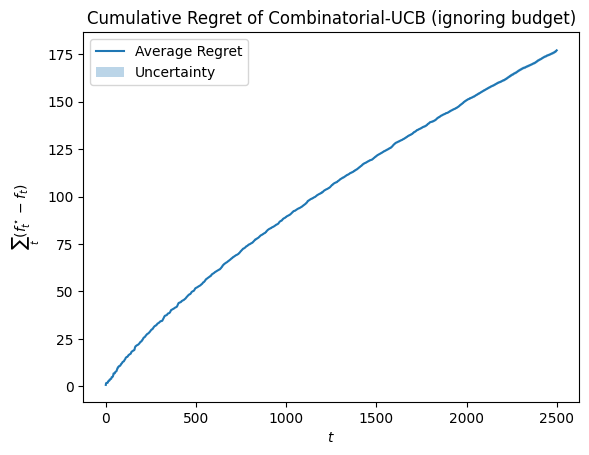

In [16]:
plt.figure()
plt.plot(np.arange(T), avg_regret_combinatorial, label='Average Regret')
plt.fill_between(np.arange(T),
                  avg_regret_combinatorial - sd_regret_combinatorial / np.sqrt(n_trials),
                  avg_regret_combinatorial + sd_regret_combinatorial / np.sqrt(n_trials),
                  alpha=0.3, label='Uncertainty')
plt.title('Cumulative Regret of Combinatorial-UCB (ignoring budget)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (f^\star_t - f_t)$')
plt.legend()
plt.show()


**How to read this graph**: same shape as Requirement 1's regret plot — a steep climb while the agent is still trying out untested $(\text{campaign},\text{bid})$ pairs, flattening out as it converges on the best compatible group of campaigns and bids. The flattening confirms the algorithm is still learning successfully even though its action space (276 feasible bundles) is $25\times$ larger than Requirement 1's, and even though the decision is now made by an integer-program solver instead of a plain `argmax`.

### Why we still need the budget-aware version

Just like in Requirement 1, this agent has no notion of a shared budget — nothing stops it from running two campaigns' worth of spending every round. The cell below logs what would happen to a nominal shared budget, purely for illustration (it does not feed back into the agent's decisions).

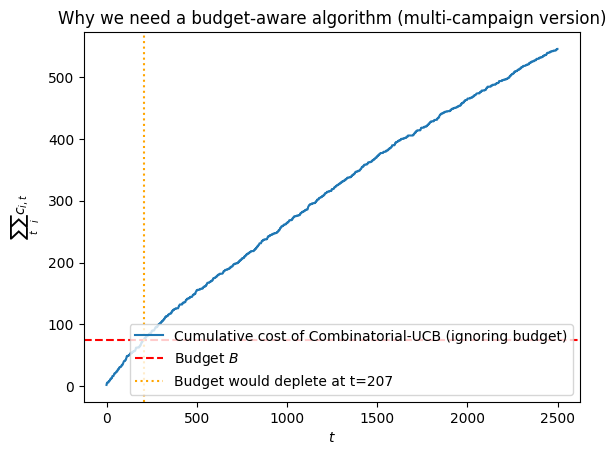

Round at which the nominal shared budget would be exhausted: 207


In [17]:
env = MultiCampaignEnvironment(valuations, m_distributions, T, seed=0)
agent = CombinatorialUCBAgent(N, n_bids, A_STRUCT, T)

costs = np.zeros(T)
for t in range(T):
    bundle = agent.pull()
    f_vec, c_vec, win_vec = env.round(bundle_to_bid_values(bundle))
    agent.update(bundle, f_vec)
    costs[t] = c_vec.sum()

cumulative_costs = np.cumsum(costs)
depletion_round = np.argmax(cumulative_costs >= B) if np.any(cumulative_costs >= B) else None

plt.figure()
plt.plot(cumulative_costs, label='Cumulative cost of Combinatorial-UCB (ignoring budget)')
plt.axhline(B, color='red', linestyle='--', label='Budget $B$')
if depletion_round is not None:
    plt.axvline(depletion_round, color='orange', linestyle=':', label=f'Budget would deplete at t={depletion_round}')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t \sum_i c_{i,t}$')
plt.title('Why we need a budget-aware algorithm (multi-campaign version)')
plt.legend()
plt.show()

print('Round at which the nominal shared budget would be exhausted:', depletion_round)


**How to read this graph**: with *two* campaigns potentially running simultaneously each round (whenever the compatible pair $\{0,2\}$ or $\{1,2\}$ is chosen), spending accumulates even faster than in the single-campaign case, and the shared budget $B$ is exhausted well before round $T$. This motivates Section 6 below exactly as it did in Requirement 1.

## 6. Algorithm — Combinatorial-UCB-Bidding (with the shared budget)

### The idea in plain words

We now add the budget by extending the integer program from Section 4 with one more row — exactly the same "add a budget constraint" move as Requirement 1's `UCBBiddingAgent`, but expressed as a MILP row instead of an LP simplex constraint:

- For every $(\text{campaign } i, \text{bid } b)$ pair, keep both an optimistic reward estimate $f_t^{\text{UCB}}(i,b)$ and an optimistic (understated) cost estimate:
$$ c_t^{\text{LCB}}(i,b) = \bar c_t(i,b) - \sqrt{\frac{2\log T}{N_{t-1}(i,b)}}. $$
- Solve:
$$
\text{bundle}_t \;=\; \arg\max_{x\,\in\,\{0,1\}^{N\times|\mathcal B|}} \ \sum_{i,b} x_{i,b}\, f_t^{\text{UCB}}(i,b)
\quad \text{s.t.} \quad
\underbrace{\sum_b x_{i,b} \le 1\ \forall i, \ \ \sum_b x_{i,b}+\sum_b x_{j,b}\le 1\ \forall (i,j)\in\text{edges}}_{\text{same structural constraints as before}},
\qquad
\underbrace{\sum_{i,b} x_{i,b}\, c_t^{\text{LCB}}(i,b) \;\le\; \rho}_{\text{new: shared budget row}}.
$$
- Play $\text{bundle}_t$ directly — **no randomization involved**: this is a deterministic combinatorial optimization, solved fresh every round with updated optimistic estimates, exactly the pattern used by `UCBKnapsackAgent` in the practical sessions (there, the "capacity" row; here, the "budget" row).
- Deduct the *total* cost across every campaign won this round from the shared budget; once it's nearly gone, stop bidding on everything.

**A trade-off worth knowing about**: Requirement 1's `UCBBiddingAgent` solved a *linear program* over a probability distribution $\gamma$ and *randomized* its bid, precisely because — under a tight budget — the true optimal policy can require mixing between two or more options (we saw this explicitly for our clairvoyant benchmark in the earlier version of this notebook: the exact optimum put $74.8\%$ weight on one bundle and $25.2\%$ on another). A deterministic MILP-based agent, by construction, can never randomize — every round it commits to one specific feasible bundle. In practice this can leave a small, persistent gap versus the fully randomized benchmark, on top of the usual learning regret. We keep the (offline, one-time) clairvoyant benchmark below as the *fully randomized* $\mathrm{OPT}^S$ regardless, both for continuity with Requirement 1 and because it remains the strongest, most standard theoretical baseline — just bear this deterministic-vs-randomized nuance in mind when reading the regret plot.

In [18]:
class CombinatorialUCBBiddingAgent:
    def __init__(self, N, n_bids, A_struct, B, T, range=1):
        self.N = N
        self.n_bids = n_bids
        self.A_struct = A_struct
        self.T = T
        self.range = range
        self.budget = B
        self.rho = B / T
        self.avg_f = np.zeros((N, n_bids))
        self.avg_c = np.zeros((N, n_bids))
        self.N_pulls = np.zeros((N, n_bids))
        self.t = 0

    def _ucb_lcb_tables(self):
        f_ucb = np.zeros((self.N, self.n_bids))
        c_lcb = np.zeros((self.N, self.n_bids))
        unexplored = self.N_pulls == 0
        large_value = (1 + np.sqrt(2 * np.log(self.T) / 1)) * 10
        f_ucb[unexplored] = large_value
        c_lcb[unexplored] = 0.0    # optimistic: assume untried pairs are free until proven otherwise
        explored = ~unexplored
        bonus = self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls[explored])
        f_ucb[explored] = self.avg_f[explored] + bonus
        c_lcb[explored] = self.avg_c[explored] - bonus
        return f_ucb, c_lcb

    def pull(self):
        if self.budget < 1:
            return []   # bid on nothing
        f_ucb, c_lcb = self._ucb_lcb_tables()
        return solve_bundle_milp(f_ucb, self.A_struct, self.n_bids, costs=c_lcb, rho=self.rho)

    def update(self, bundle, f_vec, c_vec):
        total_cost = 0.0
        for i, b in bundle:
            self.N_pulls[i, b] += 1
            self.avg_f[i, b] += (f_vec[i] - self.avg_f[i, b]) / self.N_pulls[i, b]
            self.avg_c[i, b] += (c_vec[i] - self.avg_c[i, b]) / self.N_pulls[i, b]
            total_cost += c_vec[i]
        self.budget -= total_cost
        self.t += 1


**What this class does**: same overall shape as `CombinatorialUCBAgent` above, plus cost tracking. `pull()` checks the budget first (bid nothing if it's essentially gone, exactly as the rules require), otherwise computes both UCB and LCB tables and calls `solve_bundle_milp` with the extra `costs`/`rho` arguments, which appends the budget row to the constraint matrix before solving. `update()` records outcomes for every `(campaign, bid)` pair in the played bundle and subtracts the total cost from the shared budget — identical bookkeeping to before, just summed over however many campaigns were included this round.

### 6.1 — Double-checking: is this still the "UCB-like" approach the project asks for?

The project's hint is explicit: *"Extend the 'UCB-like' approach that we saw for a single campaign to multiple campaigns."* Since Section 6's per-round solver changed from Requirement 1's linear program (with randomized sampling) to a mixed-integer program (deterministic), it's worth checking, piece by piece, that what actually makes an algorithm "UCB-like" survived the change unchanged:

| Ingredient | Requirement 1 (`UCBBiddingAgent`) | Requirement 2 (`CombinatorialUCBBiddingAgent`) | Same? |
|---|---|---|---|
| Reward estimate | $f_t^{\text{UCB}}(b) = \bar f_t(b) + \sqrt{2\log T / N_{t-1}(b)}$ | $f_t^{\text{UCB}}(i,b) = \bar f_t(i,b) + \sqrt{2\log T / N_{t-1}(i,b)}$, one per $(\text{campaign},\text{bid})$ | ✓ identical formula, just indexed by campaign as well as bid |
| Cost estimate | $c_t^{\text{LCB}}(b) = \bar c_t(b) - \sqrt{2\log T / N_{t-1}(b)}$ | $c_t^{\text{LCB}}(i,b) = \bar c_t(i,b) - \sqrt{2\log T / N_{t-1}(i,b)}$ | ✓ identical formula |
| Optimism under uncertainty | untried $b$ gets an inflated placeholder score | untried $(i,b)$ gets an inflated placeholder score | ✓ same trick, same purpose (forces exploration) |
| Per-round decision loop | *estimate → solve → play → observe → update*, every round | *estimate → solve → play → observe → update*, every round | ✓ identical loop structure |
| What changed | solve a linear program over $\Delta(\text{bids})$, then **sample** a bid from the resulting distribution | solve a mixed-integer program over feasible bundles, then **play** the arg-max bundle directly (no sampling) | this is the one real change: how the estimates get turned into an action |
| Budget bookkeeping | subtract realized cost from $B$ each round; stop bidding once $B<1$ | subtract *total* realized cost (summed across the bundle) from $B$; stop bidding once $B<1$ | ✓ identical rule |
| Feedback used to update | only for the bid actually played (bandit feedback) | only for every $(\text{campaign},\text{bid})$ pair inside the played bundle (semi-bandit feedback) | ✓ same "only observe what you played" principle, naturally extended |

So: yes, this is still the UCB-like approach from Requirement 1, extended rather than replaced. Every ingredient that makes an algorithm "UCB-like" — optimistic reward estimates, pessimistic (LCB) cost estimates under a budget, shrinking confidence radii as $N_{t-1}(i,b)$ grows, and an *estimate → solve → play → observe → update* loop repeated every round — is untouched. The only thing that changed is the *shape* of the per-round optimization problem (one bid out of $11$, vs. a compatible bundle of campaigns-and-bids out of $276$) and, as a direct consequence, which solver turns those estimates into a decision (`argmax`/LP-with-sampling vs. MILP). That is precisely what "extend to multiple campaigns" should mean: keep the learning rule fixed, generalize the action space it operates on.

As a very concrete sanity check: in the degenerate case of a *single* campaign with *no* conflict edges ($N=1$), `CombinatorialUCBBiddingAgent`'s UCB/LCB tables should reduce to *exactly* Requirement 1's formulas, since the two problems then coincide. Let's verify that numerically rather than just asserting it.

In [19]:
test_agent = CombinatorialUCBBiddingAgent(N=1, n_bids=n_bids,
                                            A_struct=build_structural_constraints(1, n_bids, []),
                                            B=10, T=100)
rng_test = np.random.default_rng(0)
for _ in range(20):
    bundle = test_agent.pull()
    f_vec = np.zeros(1)
    c_vec = np.zeros(1)
    if bundle:
        i, b = bundle[0]
        f_vec[i] = rng_test.random()
        c_vec[i] = rng_test.random() * 0.5
    test_agent.update(bundle, f_vec, c_vec)

f_ucb_test, c_lcb_test = test_agent._ucb_lcb_tables()

# Recompute Requirement 1's UCBBiddingAgent formula by hand, from the same counts/averages
counts = np.maximum(test_agent.N_pulls[0], 1)
manual_ucb = np.where(test_agent.N_pulls[0] == 0,
                       (1 + np.sqrt(2 * np.log(test_agent.T) / 1)) * 10,
                       test_agent.avg_f[0] + np.sqrt(2 * np.log(test_agent.T) / counts))
manual_lcb = np.where(test_agent.N_pulls[0] == 0,
                       0.0,
                       test_agent.avg_c[0] - np.sqrt(2 * np.log(test_agent.T) / counts))

print('UCB table matches Requirement 1 formula exactly:', np.allclose(f_ucb_test[0], manual_ucb))
print('LCB table matches Requirement 1 formula exactly:', np.allclose(c_lcb_test[0], manual_lcb))


UCB table matches Requirement 1 formula exactly: True
LCB table matches Requirement 1 formula exactly: True


**Reading the output**: both checks should print `True`. With a single campaign and no conflicts, `CombinatorialUCBBiddingAgent`'s tables are computed by literally the same formula as Requirement 1's `UCBBiddingAgent` — confirming this is a genuine *extension*, not a different algorithm that merely resembles the original.

### The clairvoyant benchmark, $\mathrm{OPT}^S$, for the multi-campaign budgeted problem

This is the one place we deliberately keep using the bundle-enumeration machinery from Section 3 — not because the *agent* needs it, but because computing the true best *randomized* policy requires mixing over the whole action space, which is naturally expressed as a linear program over all bundles (exactly Requirement 1's `compute_clairvoyant`, just with "bundles" instead of "bids"). This is a one-time, offline calculation using the *true* $\bar f, \bar c$ — nothing here runs inside the online learning loop.
$$ \mathrm{OPT}^{\text{S}} = \max_{\gamma \,\in\, \Delta(\text{BUNDLES})} \sum_{\text{bundle}} \gamma(\text{bundle})\,\bar F(\text{bundle}) \quad \text{s.t.} \quad \sum_{\text{bundle}} \gamma(\text{bundle})\,\bar C(\text{bundle}) \le \rho. $$

In [20]:
def compute_clairvoyant_bundles(bundles, f_bar, c_bar, rho):
    n_bundles = len(bundles)
    bundle_values = np.array([sum(f_bar[i, b] for i, b in bd) for bd in bundles])
    bundle_costs = np.array([sum(c_bar[i, b] for i, b in bd) for bd in bundles])
    A_ub = [bundle_costs]
    b_ub = [rho]
    A_eq = [np.ones(n_bundles)]
    b_eq = [1]
    res = optimize.linprog(-bundle_values, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1))
    gamma = res.x
    return gamma, -res.fun, bundle_costs @ gamma


gamma_clairvoyant, expected_clairvoyant_utility, expected_clairvoyant_payment = compute_clairvoyant_bundles(
    BUNDLES, f_bar, c_bar, rho)

top_bundles = np.argsort(-gamma_clairvoyant)[:5]
print('Bundles with non-negligible weight in the optimal mixture:')
for k in top_bundles:
    if gamma_clairvoyant[k] > 1e-6:
        print(f'  weight={gamma_clairvoyant[k]:.3f}  bundle={[(i, available_bids[b]) for i, b in BUNDLES[k]]}')
print(f'Expected per-round utility OPT^S = {expected_clairvoyant_utility:.4f}')
print(f'Expected per-round payment = {expected_clairvoyant_payment:.4f} (budget/round rho = {rho:.4f})')


Bundles with non-negligible weight in the optimal mixture:
  weight=0.748  bundle=[(0, np.float64(0.4)), (2, np.float64(0.30000000000000004))]
  weight=0.252  bundle=[(0, np.float64(0.4)), (2, np.float64(0.4))]
Expected per-round utility OPT^S = 0.0223
Expected per-round payment = 0.0300 (budget/round rho = 0.0300)


**Reading the output**: as flagged above, the exact optimum here genuinely *mixes* between two or more bundles whenever that's the only way to hit the budget exactly on average while maximizing reward — this is precisely the gap a deterministic MILP-based agent cannot close on its own. `Expected per-round payment` should come out at or below `rho`, confirming the mixture respects the shared budget.

### Running the experiment

Same structure as before: run the budget-aware agent for $T=2500$ rounds, across `n_trials_budget = 6` seeds (fewer trials, since solving a MILP every round is more expensive than a plain LP — but still just a few milliseconds per round). We track cumulative regret (now against $\mathrm{OPT}^S$), cumulative spending, and, for interpretability, **how often each campaign gets included** in the played bundle and **what bid it tends to receive when it is**.

In [21]:
n_trials_budget = 6

regret_per_trial_budget = []
payments_per_trial_budget = []
participation_per_trial = []   # fraction of rounds each campaign was included
avg_bid_per_trial = []         # average bid used for each campaign, when included
depletion_round_per_trial = []  # round at which each trial's shared budget first drops below 1

for seed in range(n_trials_budget):
    np.random.seed(seed)
    env = MultiCampaignEnvironment(valuations, m_distributions, T, seed=seed)
    agent = CombinatorialUCBBiddingAgent(N, n_bids, A_STRUCT, B, T)

    utilities = np.zeros(T)
    costs = np.zeros(T)
    participation_count = np.zeros(N)
    bid_sum = np.zeros(N)
    depletion_round = None

    for t in range(T):
        bundle = agent.pull()
        f_vec, c_vec, win_vec = env.round(bundle_to_bid_values(bundle))
        agent.update(bundle, f_vec, c_vec)

        utilities[t] = f_vec.sum()
        costs[t] = c_vec.sum()
        for i, b in bundle:
            participation_count[i] += 1
            bid_sum[i] += available_bids[b]
        if depletion_round is None and agent.budget < 1:
            depletion_round = t

    cumulative_regret = np.cumsum(expected_clairvoyant_utility - utilities)
    regret_per_trial_budget.append(cumulative_regret)
    payments_per_trial_budget.append(np.cumsum(costs))
    participation_per_trial.append(participation_count / T)
    avg_bid_per_trial.append(np.divide(bid_sum, participation_count,
                                        out=np.zeros(N), where=participation_count > 0))
    depletion_round_per_trial.append(depletion_round if depletion_round is not None else T)

regret_per_trial_budget = np.array(regret_per_trial_budget)
payments_per_trial_budget = np.array(payments_per_trial_budget)
participation_per_trial = np.array(participation_per_trial)
avg_bid_per_trial = np.array(avg_bid_per_trial)
depletion_round_per_trial = np.array(depletion_round_per_trial)

avg_regret_budget = regret_per_trial_budget.mean(axis=0)
sd_regret_budget = regret_per_trial_budget.std(axis=0)

avg_payments_budget = payments_per_trial_budget.mean(axis=0)
sd_payments_budget = payments_per_trial_budget.std(axis=0)

avg_participation = participation_per_trial.mean(axis=0)
avg_bid_used = avg_bid_per_trial.mean(axis=0)

print('Budget depletion round per trial:', depletion_round_per_trial)
print('Median depletion round:', int(np.median(depletion_round_per_trial)))


Budget depletion round per trial: [202 205 187 205 198 208]
Median depletion round: 203


**Reading the printed output**: this cell runs the 6 trials (each solving a MILP up to $2500$ times) and stores everything we'll plot next — including, for each trial, the exact round at which its share of the budget first drops below $1$ and it stops bidding for good. Keep the printed depletion rounds in mind for the next section: they're going to be far smaller than $T=2500$.

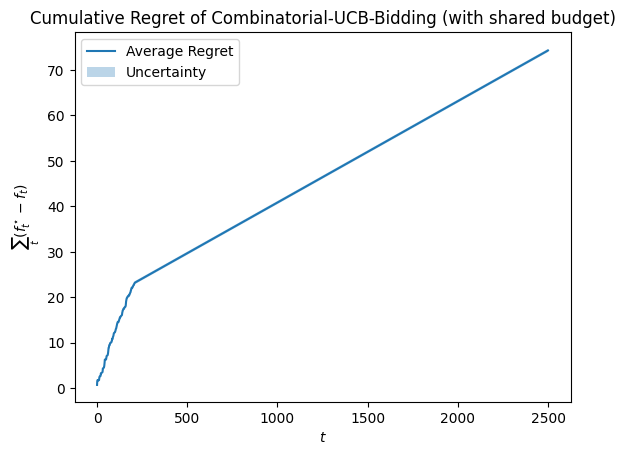

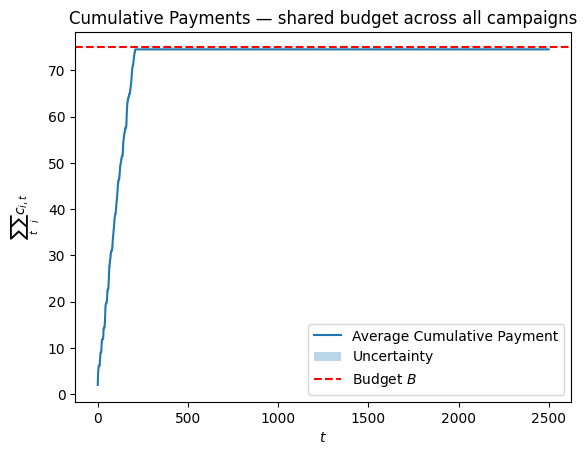

In [22]:
plt.figure()
plt.plot(np.arange(T), avg_regret_budget, label='Average Regret')
plt.fill_between(np.arange(T),
                  avg_regret_budget - sd_regret_budget / np.sqrt(n_trials_budget),
                  avg_regret_budget + sd_regret_budget / np.sqrt(n_trials_budget),
                  alpha=0.3, label='Uncertainty')
plt.title('Cumulative Regret of Combinatorial-UCB-Bidding (with shared budget)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (f^\star_t - f_t)$')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(T), avg_payments_budget, label='Average Cumulative Payment')
plt.fill_between(np.arange(T),
                  avg_payments_budget - sd_payments_budget / np.sqrt(n_trials_budget),
                  avg_payments_budget + sd_payments_budget / np.sqrt(n_trials_budget),
                  alpha=0.3, label='Uncertainty')
plt.axhline(B, color='red', linestyle='--', label='Budget $B$')
plt.title('Cumulative Payments — shared budget across all campaigns')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t \sum_i c_{i,t}$')
plt.legend()
plt.show()


**How to read these two graphs — and why the tail looks perfectly straight, not concave**: look closely and both curves have an elbow: a short, concave, "learning" stretch (roughly the first couple hundred rounds — compare to the depletion rounds printed above), followed by a dead-straight line for the rest of the $2500$-round horizon. That straight line is not a plotting artifact and it is not the algorithm "giving up on learning" — it is completely mechanical. Once `agent.budget < 1`, `pull()` returns `[]` for every remaining round: zero bids, zero cost, zero utility, forever. With realized utility pinned at exactly $0$ every round, `cumulative_regret = np.cumsum(expected_clairvoyant_utility - utilities)` necessarily grows by the *exact same constant* every single round after that — a straight line by construction, no randomness left to bend it. Likewise, `avg_payments_budget` goes flat because there is, quite literally, nothing left to spend.

The real question this raises is *why* the budget disappears after only a couple hundred rounds out of $2500$ — that traces back to the same "untried pairs are assumed free" optimism discussed in Section 6.1: while any of the $33$ $(\text{campaign},\text{bid})$ pairs are still unexplored, the budget constraint in the MILP is trivially satisfied (an assumed cost of $0$ is always $\le \rho$), so the algorithm spends aggressively during the pure-exploration phase, well above the $\rho=0.03$/round pace it settles into afterward — and by the time the LCB estimates become informative, a large chunk of the shared budget $B=75$ is already gone.

### Why this looks so different from `09_combinatorial_mabs.ipynb`'s knapsack regret plot

If you compare this to the smooth, ever-climbing, concave curve `UCBKnapsackAgent` produces over $T=10{,}000$ rounds in the practical session notebook, the shapes look nothing alike — and that's expected, not a discrepancy to fix. That notebook is explicit about the distinction, right where it introduces the knapsack problem: *"Remark: this is **not** the budget constraint of the previous lectures."* Its capacity $C$ is a **per-round, recurring** resource — every round starts fresh with the full capacity $C=10$ available again, so nothing ever "runs out" over the horizon, and the agent just keeps refining which items it packs, forever. Our $B$ is exactly the "previous lectures'" kind of constraint instead (the Bandits-with-Knapsacks setup the project itself asks for): a **one-time, total** budget spent down cumulatively *across* the whole horizon, which can — and, with this much early over-exploration, does — hit zero well before $T$. Both regret curves are behaving exactly as their respective constraint types should; the mismatch in shape is the signature of the two being genuinely different problems, not a bug in either notebook.

### Zooming in on the part that actually reflects learning

Since the interesting dynamics are compressed into the first few hundred rounds, let's zoom the x-axis in to roughly $3\times$ the median depletion round, so the concave "still learning" portion isn't squashed flat by $2000+$ rounds of an uneventful straight line.

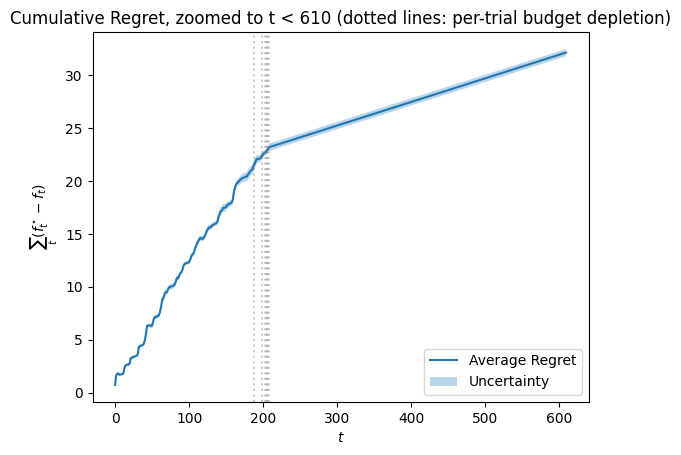

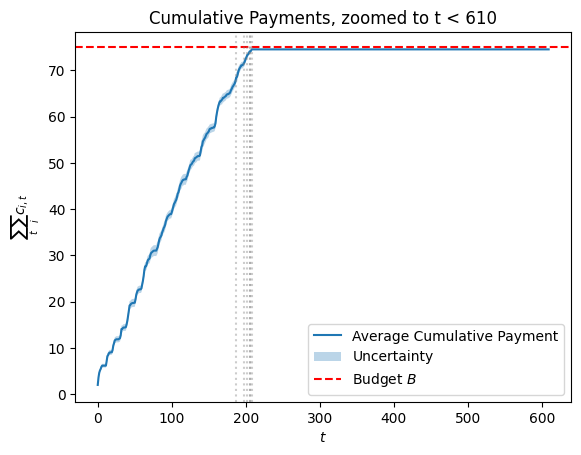

In [23]:
zoom_t = min(T, int(np.median(depletion_round_per_trial) * 3))

plt.figure()
plt.plot(np.arange(zoom_t), avg_regret_budget[:zoom_t], label='Average Regret')
plt.fill_between(np.arange(zoom_t),
                  (avg_regret_budget - sd_regret_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  (avg_regret_budget + sd_regret_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  alpha=0.3, label='Uncertainty')
for d in depletion_round_per_trial:
    plt.axvline(d, color='gray', linestyle=':', alpha=0.4)
plt.title(f'Cumulative Regret, zoomed to t < {zoom_t} (dotted lines: per-trial budget depletion)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (f^\star_t - f_t)$')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(zoom_t), avg_payments_budget[:zoom_t], label='Average Cumulative Payment')
plt.fill_between(np.arange(zoom_t),
                  (avg_payments_budget - sd_payments_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  (avg_payments_budget + sd_payments_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  alpha=0.3, label='Uncertainty')
plt.axhline(B, color='red', linestyle='--', label='Budget $B$')
for d in depletion_round_per_trial:
    plt.axvline(d, color='gray', linestyle=':', alpha=0.4)
plt.title(f'Cumulative Payments, zoomed to t < {zoom_t}')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t \sum_i c_{i,t}$')
plt.legend()
plt.show()


**How to read the zoomed-in graphs**: now the concave, diminishing-regret shape you'd expect from any UCB-style algorithm is visible — regret grows quickly while the algorithm is still trying untested $(\text{campaign},\text{bid})$ pairs, then bends over as its estimates sharpen. The dotted vertical lines mark exactly where each of the $6$ trials ran out of budget; every trial's curve turns into a straight line right at its own dotted line, which is the clearest possible visual confirmation of the "budget hits zero $\Rightarrow$ forced straight line" mechanism explained above. The payments plot tells the same story from the spending side: cumulative payment climbs quickly toward $B$ and then goes flat right where the budget runs out — the *average* across trials stays just at or under $B$, though an individual trial can end a whisker above it (by at most one round's worth of spending), since the depletion check happens *before* a round is played, not after; the overspend is bounded, not runaway, precisely because bid amounts are now correctly scaled (see the earlier fix to `bundle_to_bid_values`).

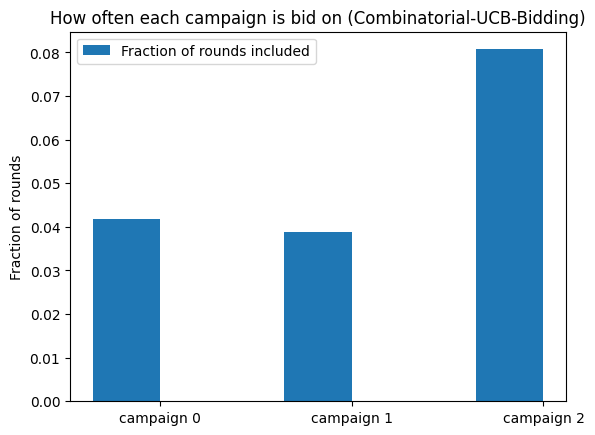

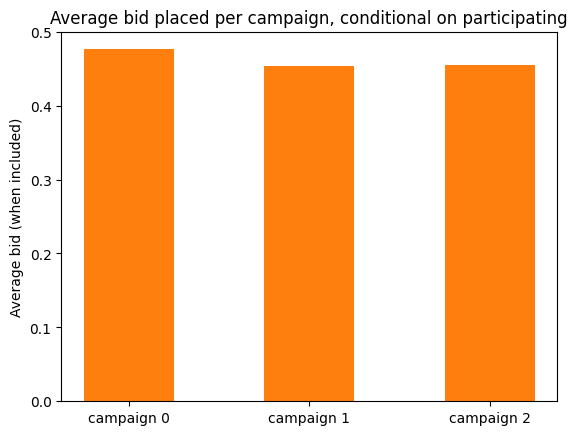

In [24]:
plt.figure()
x = np.arange(N)
width = 0.35
plt.bar(x - width/2, avg_participation, width=width, label='Fraction of rounds included')
plt.xticks(x, [f'campaign {i}' for i in range(N)])
plt.ylabel('Fraction of rounds')
plt.title('How often each campaign is bid on (Combinatorial-UCB-Bidding)')
plt.legend()
plt.show()

plt.figure()
plt.bar(x, avg_bid_used, width=0.5, color='C1')
plt.xticks(x, [f'campaign {i}' for i in range(N)])
plt.ylabel('Average bid (when included)')
plt.title('Average bid placed per campaign, conditional on participating')
plt.show()


**How to read these graphs**: the first bar chart shows what fraction of the $2500$ rounds each campaign was actually included in the played bundle — since campaigns $0$ and $1$ can never both run, and the budget is limited, you should see the algorithm favoring whichever combination is most profitable overall (recall from the clairvoyant computation which bundles carried the most weight) rather than spreading attention equally across all three campaigns. The second chart shows the average bid used *when* a campaign was included — compare these values to each campaign's individual win-probability curve from Section 2 to sanity-check that the learned bids sit in a sensible range.

## 7. Comparing both algorithms

Same caveat as Requirement 1: the two regret curves use *different* benchmarks (best fixed feasible bundle with no budget, vs. the fully randomized $\mathrm{OPT}^S$ with the shared budget respected), so this is about confirming *both* learn successfully, not about which number is smaller.

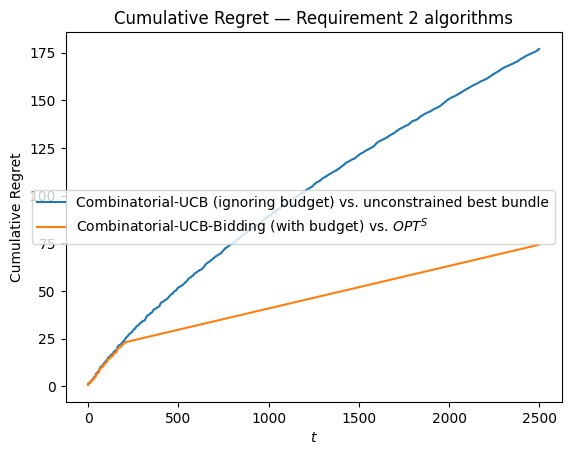

Final average regret — Combinatorial-UCB (ignoring budget): 177.01
Final average regret — Combinatorial-UCB-Bidding (with budget): 74.29


In [25]:
plt.figure()
plt.plot(np.arange(T), avg_regret_combinatorial, label='Combinatorial-UCB (ignoring budget) vs. unconstrained best bundle')
plt.plot(np.arange(T), avg_regret_budget, label='Combinatorial-UCB-Bidding (with budget) vs. $OPT^S$')
plt.title('Cumulative Regret — Requirement 2 algorithms')
plt.xlabel('$t$')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.show()

print(f'Final average regret — Combinatorial-UCB (ignoring budget): {avg_regret_combinatorial[-1]:.2f}')
print(f'Final average regret — Combinatorial-UCB-Bidding (with budget): {avg_regret_budget[-1]:.2f}')


**How to read this graph and the numbers below it**: the no-budget curve should flatten out essentially completely (nothing stops it from matching its benchmark exactly once it's learned enough). The budget-aware curve may keep a gentle upward drift even late in the horizon, for the reason discussed in Section 6 — a real, honest artifact of using a deterministic solver against a randomized benchmark, not a bug.

## 8. Concluding remarks

1. **The per-round decision is now solved exactly like the practical sessions solve combinatorial problems**: an integer program (`scipy.optimize.milp`), with two structural constraint families (one bid per campaign, respect the conflict graph) built once and reused every round, plus — for the budgeted agent — one additional budget row rebuilt from fresh UCB/LCB estimates each round. This mirrors `UCBMatchingAgent`/`UCBKnapsackAgent` from `09_combinatorial_mabs.ipynb` far more closely than the brute-force version did.
2. **Brute-force bundle listing is kept only as an optional tool**: once (Section 4) to sanity-check the MILP solver against exhaustive search, and once more (Section 6) to compute the offline, fully-randomized clairvoyant benchmark — never inside the online learning loop.
3. **Semi-bandit feedback is still what keeps this tractable**: even though the feasible region has $276$ bundles, we only ever learn statistics for the $33$ individual $(\text{campaign},\text{bid})$ pairs.
4. **A genuine trade-off, not swept under the rug**: because the MILP-based agent is deterministic, it cannot in general match a benchmark that requires randomizing between bundles — as our own clairvoyant computation showed happens here. Requirement 1's LP-with-randomization approach doesn't have this issue, at the cost of needing to enumerate (or otherwise represent) the full action space to define the distribution $\gamma$ over it. Which approach is "better" is a real, scale-dependent engineering trade-off — MILP scales to far more campaigns and richer constraints (matroids, cardinality limits, etc.), while randomized LPs give a tighter theoretical guarantee when the action space is small enough to enumerate.
5. **What comes next (Requirement 3)**: keep this same multi-campaign, budget-constrained, combinatorial structure, but now also build a **non-stationary / adversarial** environment and a **primal-dual** bidding strategy (Lagrangian relaxation of the budget, à la slide deck 7) that performs well in *both* the stochastic environment from this notebook and a more adversarial one — the "best-of-both-worlds" requirement.
